In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
from joblib import dump
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    precision_recall_fscore_support,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

torch.manual_seed(42)


In [2]:
df = pd.read_parquet("data_clean.parquet")
# Nur vorhandene float-Features verwenden
X = df.select_dtypes(include=['float32']).copy()
# Target zuverlässig in bool konvertieren
y = df['target'].astype(str).str.strip().str.lower() == 'true'

# Team-Split-Protokoll: 80% Development / 20% finaler Holdout,
# stratifiziert nach target, random_state=42 - der Holdout wird
# erst ganz am Ende genau einmal angefasst, damit alle im Team auf
# denselben 20% final bewerten.
X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Innerhalb der Development-Daten: eigene 80/20-Aufteilung für
# Training / Early Stopping / Threshold-Wahl.
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=42
)

print('Sizes: dev_train', len(X_train), 'dev_val', len(X_val), 'holdout', len(X_holdout))

# StandardScaler: laut EDA reicht Z-Standardisierung, Ausreißeranteil
# ist vernachlässigbar (Median 0.02%) - Robust-/MinMax-Skalierung
# bringen hier keinen Mehrwert.
scaler = StandardScaler()

# Fit nur auf normalen (target=0) Dev-Train-Zeilen - semi-supervised:
# der Autoencoder sieht beim Training nie eine Anomalie, Labels werden
# nur zur Trainingsdaten-Filterung genutzt, nie in der Loss selbst.
X_train_norm = X_train[~y_train].values
scaler.fit(X_train_norm)

X_train_norm_s = scaler.transform(X_train_norm)   # nur normale Dev-Train-Proben für Autoencoder-Training
X_val_s = scaler.transform(X_val.values)           # Dev-Val (gesamt, für Early Stopping / Threshold)
X_holdout_s = scaler.transform(X_holdout.values)   # Holdout (gesamt, nur finale Bewertung)

dump(scaler, "scaler_standard.joblib")

print(f"Scaler: fitted on {X_train_norm.shape[0]} normal dev-train samples")


Sizes: dev_train 128000 dev_val 32000 holdout 40000
Scaler: fitted on 115138 normal dev-train samples


In [3]:
# ============================================================
# Training (Dev-Train, nur target = 0)
# ============================================================

X_train_tensor = torch.tensor(
    X_train_norm_s,
    dtype=torch.float32
)

train_ds = TensorDataset(
    X_train_tensor,
    X_train_tensor
)

train_loader = DataLoader(
    train_ds,
    batch_size=1024,
    shuffle=True
)


# ============================================================
# Dev-Val: X + echte Labels (Early Stopping / Threshold-Wahl)
# ============================================================

X_val_tensor = torch.tensor(
    X_val_s,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val.values.astype(int),
    dtype=torch.long
)

val_ds = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

val_loader = DataLoader(
    val_ds,
    batch_size=1024,
    shuffle=False
)


# ============================================================
# Holdout: X + echte Labels (wird erst bei der finalen
# Evaluation ein einziges Mal ausgewertet)
# ============================================================

X_holdout_tensor = torch.tensor(
    X_holdout_s,
    dtype=torch.float32
)

y_holdout_tensor = torch.tensor(
    y_holdout.values.astype(int),
    dtype=torch.long
)

holdout_ds = TensorDataset(
    X_holdout_tensor,
    y_holdout_tensor
)

holdout_loader = DataLoader(
    holdout_ds,
    batch_size=1024,
    shuffle=False
)


# NumPy Labels für spätere Evaluation
y_val_arr = y_val.values.astype(int)
y_holdout_arr = y_holdout.values.astype(int)


print("train_norm shape:", X_train_norm_s.shape)
print("dev_val shape:", X_val_s.shape)
print("holdout shape:", X_holdout_s.shape)

print()
print("Dev-Val target 0:", np.sum(y_val_arr == 0))
print("Dev-Val target 1:", np.sum(y_val_arr == 1))
print("Holdout target 0:", np.sum(y_holdout_arr == 0))
print("Holdout target 1:", np.sum(y_holdout_arr == 1))


train_norm shape: (115138, 200)
dev_val shape: (32000, 200)
holdout shape: (40000, 200)

Dev-Val target 0: 28784
Dev-Val target 1: 3216
Holdout target 0: 35980
Holdout target 1: 4020


In [4]:
class MyAutoencoder(nn.Module):
    def __init__(self, input_dim, lat_space_dim, dropout=0.15, leaky_slope=0.2):
        super().__init__()

        # Einzelne Zwischenschicht statt drei Kompressionsstufen: bei
        # 200 praktisch unkorrelierten Features (siehe EDA, alle |r| < 0.05)
        # gibt es keine Redundanz, die eine tiefere Kaskade ausnutzen könnte.
        hidden_dim = int(round((input_dim + lat_space_dim) / 2))

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(leaky_slope),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, lat_space_dim)  # latent space
        )

        self.decoder = nn.Sequential(
            nn.Linear(lat_space_dim, hidden_dim),
            nn.LeakyReLU(leaky_slope),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, input_dim)  # roher Regressionsoutput
        )

    def forward(self, x):
        z = self.encoder(x)  # encode input in z
        x_hat = self.decoder(z)  # reconstruct from z
        return x_hat


In [5]:
input_dim = X_train_tensor.shape[1]
lat_space_dim = 32          # bestes latent_dim aus dem Hyperparameter-Sweep
n_epochs = 150
patience = 10                # Early Stopping auf val-AUC


model = MyAutoencoder(
    input_dim=input_dim,
    lat_space_dim=lat_space_dim,
    dropout=0.15
)

loss_fn = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0003
)


train_losses = []

val_losses = []
val_losses_target_0 = []
val_losses_target_1 = []
val_aucs = []

train_size = len(train_loader.dataset)

best_val_auc = -1.0
best_epoch = -1
best_state = None
no_improve = 0


for epoch in range(1, n_epochs + 1):

    # ========================================================
    # Training (kein Denoising-Rauschen: bei praktisch
    # unkorrelierten Features kann das Netz eine verrauschte
    # Zelle nicht aus anderen Features rekonstruieren)
    # ========================================================

    model.train()

    running_train_loss = 0.0

    for x_train_batch, _ in train_loader:

        x_hat = model(x_train_batch)

        train_loss = loss_fn(
            x_hat,
            x_train_batch
        )

        optimizer.zero_grad()
        train_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        batch_size = x_train_batch.size(0)

        running_train_loss += (
            train_loss.item() * batch_size
        )


    epoch_train_loss = (
        running_train_loss / train_size
    )

    train_losses.append(
        epoch_train_loss
    )


    # ========================================================
    # Validation (Dev-Val)
    # ========================================================

    model.eval()

    val_errors_all = []
    val_errors_target_0 = []
    val_errors_target_1 = []


    with torch.no_grad():

        for x_val_batch, y_val_batch in val_loader:

            x_hat_val = model(x_val_batch)

            # Rekonstruktionsfehler pro Sample
            reconstruction_error = (
                (x_hat_val - x_val_batch) ** 2
            ).mean(dim=1)


            # Alle Samples
            val_errors_all.extend(
                reconstruction_error.cpu().numpy()
            )


            # Nur target = 0
            mask_0 = (y_val_batch == 0)

            val_errors_target_0.extend(
                reconstruction_error[mask_0]
                .cpu()
                .numpy()
            )


            # Nur target = 1
            mask_1 = (y_val_batch == 1)

            val_errors_target_1.extend(
                reconstruction_error[mask_1]
                .cpu()
                .numpy()
            )


    # ========================================================
    # Mean Reconstruction Error + val-AUC
    # ========================================================

    epoch_val_loss = np.mean(
        val_errors_all
    )

    epoch_val_loss_0 = np.mean(
        val_errors_target_0
    )

    epoch_val_loss_1 = np.mean(
        val_errors_target_1
    )

    epoch_val_auc = roc_auc_score(
        y_val_arr,
        val_errors_all
    )


    val_losses.append(
        epoch_val_loss
    )

    val_losses_target_0.append(
        epoch_val_loss_0
    )

    val_losses_target_1.append(
        epoch_val_loss_1
    )

    val_aucs.append(
        epoch_val_auc
    )


    # ========================================================
    # Early Stopping auf val-AUC: bestes state_dict sichern,
    # statt am Ende einfach den letzten Trainingsstand zu nehmen
    # ========================================================

    if epoch_val_auc > best_val_auc:
        best_val_auc = epoch_val_auc
        best_epoch = epoch
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1


    print(
        f"Epoch {epoch:3d}: "
        f"train={epoch_train_loss:.5f} | "
        f"val AUC={epoch_val_auc:.4f} (best={best_val_auc:.4f} @ {best_epoch}) | "
        f"val target 0={epoch_val_loss_0:.5f} | "
        f"val target 1={epoch_val_loss_1:.5f}"
    )

    if no_improve >= patience:
        print(f"\nEarly Stopping nach Epoche {epoch} (keine Verbesserung seit {patience} Epochen)")
        break


# Bestes Modell (höchste val-AUC) wiederherstellen
model.load_state_dict(best_state)
print(f"\nBestes Modell: Epoche {best_epoch}, val-AUC={best_val_auc:.4f}")


Epoch   1: train=0.96869 | val AUC=0.7308 (best=0.7308 @ 1) | val target 0=0.91528 | val target 1=0.99051
Epoch   2: train=0.90245 | val AUC=0.7227 (best=0.7308 @ 1) | val target 0=0.86605 | val target 1=0.93739
Epoch   3: train=0.88102 | val AUC=0.7220 (best=0.7308 @ 1) | val target 0=0.85739 | val target 1=0.92842
Epoch   4: train=0.87516 | val AUC=0.7209 (best=0.7308 @ 1) | val target 0=0.85485 | val target 1=0.92539
Epoch   5: train=0.87188 | val AUC=0.7202 (best=0.7308 @ 1) | val target 0=0.85301 | val target 1=0.92321
Epoch   6: train=0.86944 | val AUC=0.7199 (best=0.7308 @ 1) | val target 0=0.85152 | val target 1=0.92161
Epoch   7: train=0.86744 | val AUC=0.7194 (best=0.7308 @ 1) | val target 0=0.85034 | val target 1=0.92024
Epoch   8: train=0.86581 | val AUC=0.7187 (best=0.7308 @ 1) | val target 0=0.84938 | val target 1=0.91902
Epoch   9: train=0.86436 | val AUC=0.7189 (best=0.7308 @ 1) | val target 0=0.84849 | val target 1=0.91820
Epoch  10: train=0.86320 | val AUC=0.7190 (bes

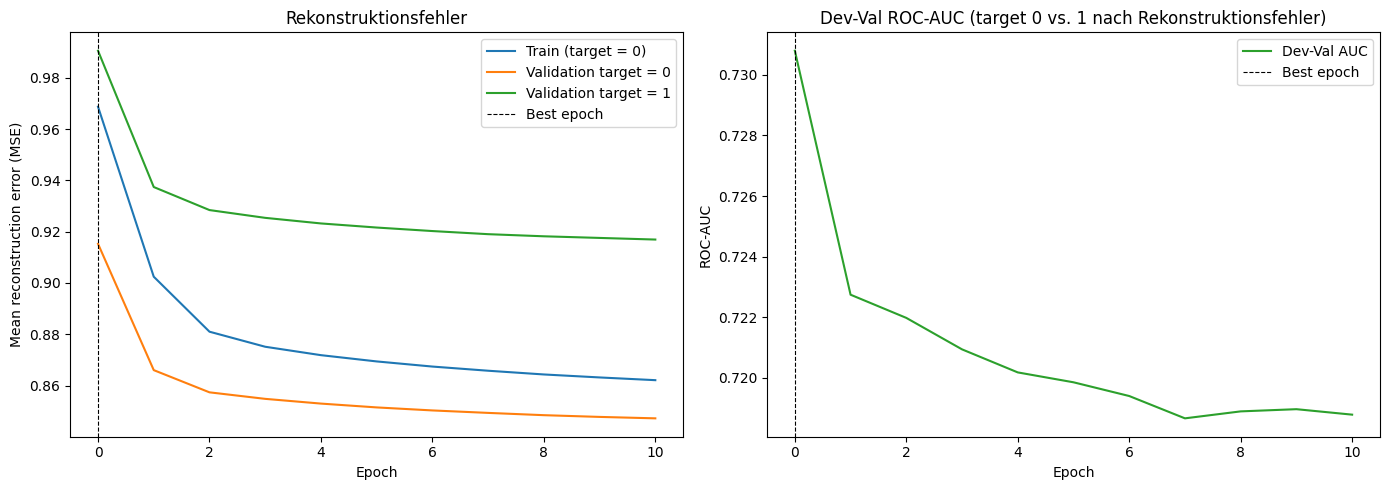

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label="Train (target = 0)")
axes[0].plot(val_losses_target_0, label="Validation target = 0")
axes[0].plot(val_losses_target_1, label="Validation target = 1")
axes[0].axvline(best_epoch - 1, color="black", linestyle="--", linewidth=0.8, label="Best epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean reconstruction error (MSE)")
axes[0].set_title("Rekonstruktionsfehler")
axes[0].legend()

axes[1].plot(val_aucs, color="tab:green", label="Dev-Val AUC")
axes[1].axvline(best_epoch - 1, color="black", linestyle="--", linewidth=0.8, label="Best epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("Dev-Val ROC-AUC (target 0 vs. 1 nach Rekonstruktionsfehler)")
axes[1].legend()

plt.tight_layout()
plt.show()


Dev-Val reconstruction error:
target 0: mean=0.915275, median=0.912860
target 1: mean=0.990511, median=0.988956

Holdout reconstruction error:
target 0: mean=0.915423, median=0.913870
target 1: mean=0.985242, median=0.984329

Threshold (F1-optimal auf Dev-Val): 1.002093e+00 (Dev-Val-F1: 0.3251)

Holdout-Ergebnis:
ROC-AUC:   0.7182
PR-AUC:    0.2468
Precision: 0.2393
Recall:    0.4139
F1:        0.3032
MCC:       0.2117


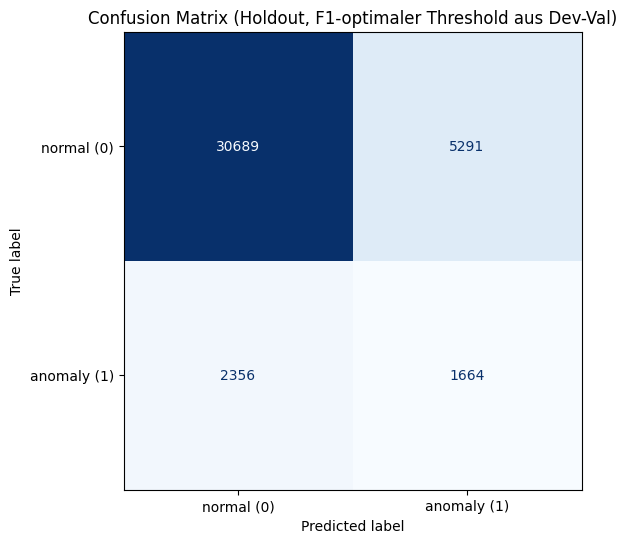

True Negatives:  30689
False Positives: 5291
False Negatives: 2356
True Positives:  1664


,Modell / Variante,Count Encoding,PR-AUC / AP,ROC-AUC,F1,MCC,Precision,Recall,Threshold
0,"Autoencoder (semi-supervised, normal-only)",False,0.2468,0.7182,0.3032,0.2117,0.2393,0.4139,1.002093


In [7]:
model.eval()

recon_val = []
recon_holdout = []

labels_val = []
labels_holdout = []


with torch.no_grad():

    # ========================================================
    # Dev-Val (für Threshold-Wahl)
    # ========================================================

    for xb, yb in val_loader:

        x_hat = model(xb)

        batch_error = (
            (x_hat - xb) ** 2
        ).mean(dim=1)

        recon_val.extend(
            batch_error.cpu().numpy()
        )

        labels_val.extend(
            yb.cpu().numpy()
        )


    # ========================================================
    # Holdout (wird hier zum ersten und einzigen Mal ausgewertet)
    # ========================================================

    for xb, yb in holdout_loader:

        x_hat = model(xb)

        batch_error = (
            (x_hat - xb) ** 2
        ).mean(dim=1)

        recon_holdout.extend(
            batch_error.cpu().numpy()
        )

        labels_holdout.extend(
            yb.cpu().numpy()
        )


recon_val = np.array(recon_val)
recon_holdout = np.array(recon_holdout)

y_val_arr = np.array(labels_val)
y_holdout_arr = np.array(labels_holdout)


# ============================================================
# Reconstruction Error nach Klasse
# ============================================================

val_error_target_0 = recon_val[
    y_val_arr == 0
]

val_error_target_1 = recon_val[
    y_val_arr == 1
]


holdout_error_target_0 = recon_holdout[
    y_holdout_arr == 0
]

holdout_error_target_1 = recon_holdout[
    y_holdout_arr == 1
]


print("Dev-Val reconstruction error:")
print(
    f"target 0: mean={val_error_target_0.mean():.6f}, "
    f"median={np.median(val_error_target_0):.6f}"
)

print(
    f"target 1: mean={val_error_target_1.mean():.6f}, "
    f"median={np.median(val_error_target_1):.6f}"
)


print("\nHoldout reconstruction error:")
print(
    f"target 0: mean={holdout_error_target_0.mean():.6f}, "
    f"median={np.median(holdout_error_target_0):.6f}"
)

print(
    f"target 1: mean={holdout_error_target_1.mean():.6f}, "
    f"median={np.median(holdout_error_target_1):.6f}"
)


# ============================================================
# Threshold auf Dev-Val bestimmen (F1-optimal), unverändert auf
# den Holdout anwenden - der Holdout selbst beeinflusst den
# Threshold nie.
# ============================================================

prec_curve, rec_curve, thresh_curve = (
    precision_recall_curve(
        y_val_arr,
        recon_val
    )
)

f1_curve = (
    2 * prec_curve * rec_curve
    / (prec_curve + rec_curve + 1e-12)
)

best_idx = np.argmax(
    f1_curve[:-1]
)

threshold = thresh_curve[
    best_idx
]


print(
    f"\nThreshold (F1-optimal auf Dev-Val): "
    f"{threshold:.6e} "
    f"(Dev-Val-F1: {f1_curve[best_idx]:.4f})"
)


# ============================================================
# Holdout-Evaluation - vollständige Metriken-Tabelle
# (Team-Format: Modell | Count Encoding | PR-AUC/AP | ROC-AUC |
#  F1 | MCC | Precision | Recall | Threshold)
# ============================================================

y_pred = (
    recon_holdout > threshold
).astype(int)

roc_auc = roc_auc_score(
    y_holdout_arr,
    recon_holdout
)

pr_auc = average_precision_score(
    y_holdout_arr,
    recon_holdout
)

precision, recall, f1, _ = (
    precision_recall_fscore_support(
        y_holdout_arr,
        y_pred,
        average="binary",
        zero_division=0
    )
)

mcc = matthews_corrcoef(
    y_holdout_arr,
    y_pred
)

results_row = {
    "Modell / Variante": "Autoencoder (semi-supervised, normal-only)",
    "Count Encoding": False,
    "PR-AUC / AP": round(pr_auc, 4),
    "ROC-AUC": round(roc_auc, 4),
    "F1": round(f1, 4),
    "MCC": round(mcc, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "Threshold": threshold,
}
results_table = pd.DataFrame([results_row])

print("\nHoldout-Ergebnis:")
print(
    f"ROC-AUC:   {roc_auc:.4f}\n"
    f"PR-AUC:    {pr_auc:.4f}\n"
    f"Precision: {precision:.4f}\n"
    f"Recall:    {recall:.4f}\n"
    f"F1:        {f1:.4f}\n"
    f"MCC:       {mcc:.4f}"
)

cm = confusion_matrix(
    y_holdout_arr,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["normal (0)", "anomaly (1)"]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

ax.set_title("Confusion Matrix (Holdout, F1-optimaler Threshold aus Dev-Val)")
plt.tight_layout()
plt.show()


# ============================================================
# Werte einzeln ausgeben
# ============================================================

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

results_table


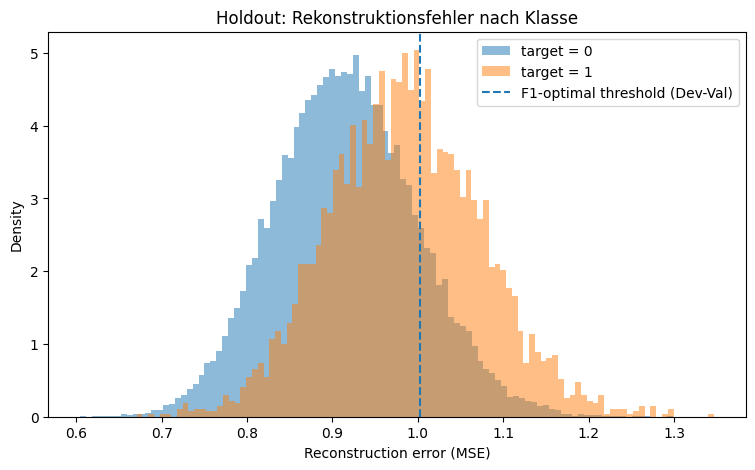

In [8]:
plt.figure(figsize=(9, 5))

plt.hist(
    holdout_error_target_0,
    bins=100,
    density=True,
    alpha=0.5,
    label="target = 0"
)

plt.hist(
    holdout_error_target_1,
    bins=100,
    density=True,
    alpha=0.5,
    label="target = 1"
)

plt.axvline(
    threshold,
    linestyle="--",
    label="F1-optimal threshold (Dev-Val)"
)

plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Density")
plt.title("Holdout: Rekonstruktionsfehler nach Klasse")
plt.legend()

plt.show()
